In [3]:
from neuralprophet import NeuralProphet
NeuralProphet()

In [4]:
import sys
import os

# Ajouter la racine du projet au PYTHONPATH
sys.path.append(os.path.abspath("../.."))

import pandas as pd
from src.prediction.time_series import train_prophet, forecast_prophet


# Charger le dataset d'exemple
df = pd.read_csv("../../data/examples/urgences_exemple.csv")

# Convertir la colonne datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# Vérifier la structure
df.head()

,datetime,arrivals
0,2024-01-01 00:00:00,16.0
1,2024-01-01 01:00:00,15.0
2,2024-01-01 02:00:00,16.0
3,2024-01-01 03:00:00,18.0
4,2024-01-01 04:00:00,15.0


In [28]:
import pandas as pd
from neuralprophet import NeuralProphet

def train_prophet(df: pd.DataFrame, date_col: str, target_col: str):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model

def train_prophet(df, date_col, target_col):
    model_df = df[[date_col, target_col]].rename(columns={date_col: "ds", target_col: "y"})
    model = NeuralProphet()
    model.fit(model_df, freq="H")
    return model, model_df





WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (N

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (34) is too small than the required number                     for the learning rate finder (233). The results might not be optimal.
Finding best initial lr: 100%|██████████| 233/233 [00:02<00:00, 94.76it/s]


Training: |          | 0/? [00:27<?, ?it/s, v_num=16, train_loss=0.030, reg_loss=0.000, MAE=1.610, RMSE=2.020, Loss=0.0299, RegLoss=0.000] 

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency h corresponds to 99.954% of the data.
WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1173: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  aux_ts = pd.DataFrame(pd.date_range("1994-01-01", periods=100, freq=freq_str))

WARNING - (py.warnings._showwarnmsg) - c:\Users\jonat\anaconda3\envs\urgences\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype


Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 166.66it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


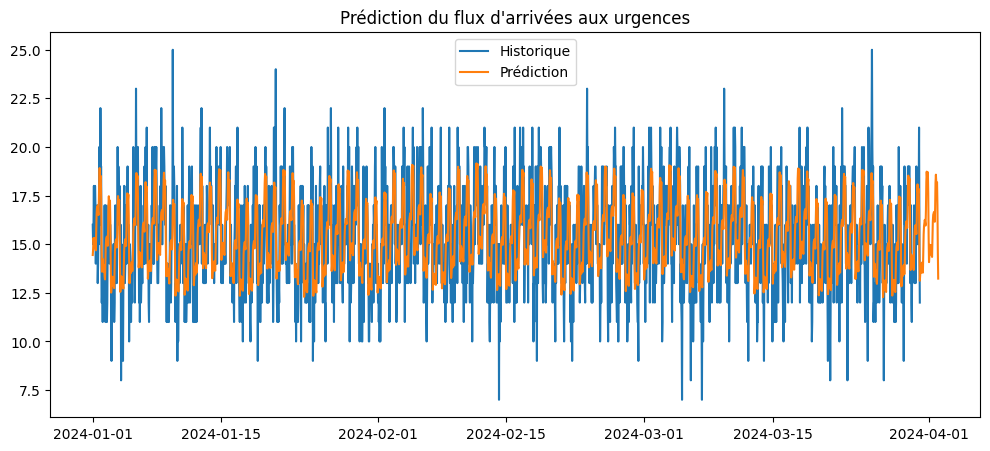

In [ ]:
import matplotlib.pyplot as plt

model, model_df = train_prophet(df, "datetime", "arrivals")
forecast = forecast_prophet(model, model_df, periods=48)
#forecast.head()
#forecast.columns

plt.figure(figsize=(12, 5))
plt.plot(df["datetime"], df["arrivals"], label="Historique")
plt.plot(forecast["ds"], forecast["yhat1"], label="Prédiction")
plt.legend()
plt.title("Prédiction du flux d'arrivées aux urgences")
plt.show()
